# Relaciones entre divorcios y violencia intrafamiliar
Este cuaderno explora las asociaciones entre los indicadores numéricos principales:
divorcios, VIF total, desagregados por sexo y por tipo de agresión. Se incluyen
dispersogramas, correlaciones (Spearman/Pearson) y tablas por cuantiles.

In [3]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != 'MD_Proyecto1':
    for parent in PROJECT_ROOT.parents:
        if parent.name == 'MD_Proyecto1':
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import data_pipeline as dp
dp = importlib.reload(dp)

# Generamos el panel sólo con los años que existen en ambos orígenes
panel = dp.build_panel(force_rebuild=False, only_common_years=True).dropna(subset=['departamento', 'anio']).copy()
panel[['divorcios_total', 'vif_total']] = panel[['divorcios_total', 'vif_total']].fillna(0)
print(
    f"Panel limitado a {panel['anio'].nunique()} años comunes: {panel['anio'].min()}-{panel['anio'].max()}"
    )

Panel limitado a 24 años comunes: 2000-2023


## Dispersogramas y coeficientes
Se calculan correlaciones Spearman (robusta a outliers) y Pearson sobre los datos
log-transformados (`log1p`).

Spearman: 0.685
Pearson con log1p: 0.827


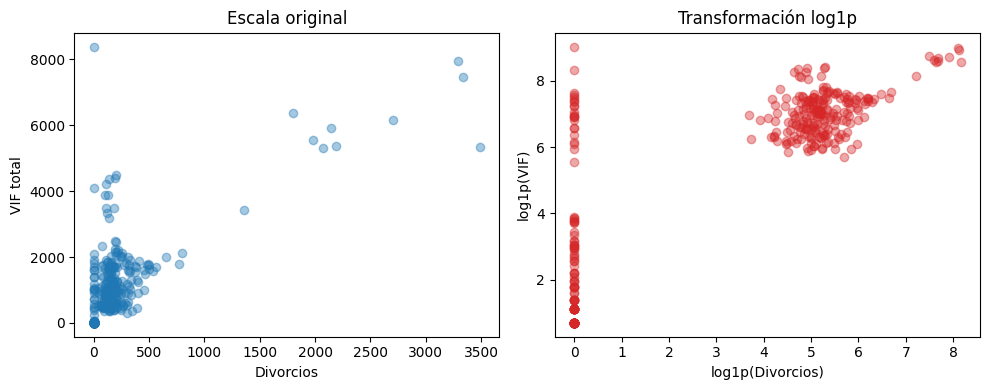

In [4]:
pareja = panel[['divorcios_total', 'vif_total']].replace({np.inf: np.nan, -np.inf: np.nan}).dropna()
spearman = pareja.corr(method='spearman').loc['divorcios_total', 'vif_total']
pearson_log = np.corrcoef(np.log1p(pareja['divorcios_total']), np.log1p(pareja['vif_total']))[0, 1]
print(f"Spearman: {spearman:.3f}")
print(f"Pearson con log1p: {pearson_log:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(pareja['divorcios_total'], pareja['vif_total'], alpha=0.4, color='#1f77b4')
axes[0].set_xlabel('Divorcios')
axes[0].set_ylabel('VIF total')
axes[0].set_title('Escala original')

axes[1].scatter(np.log1p(pareja['divorcios_total']), np.log1p(pareja['vif_total']), alpha=0.4, color='#d62728')
axes[1].set_xlabel('log1p(Divorcios)')
axes[1].set_ylabel('log1p(VIF)')
axes[1].set_title('Transformación log1p')
plt.tight_layout()

## Matriz de correlaciones
Se incluyen divorcios, VIF total, composición por sexo y los tres tipos principales de agresión.

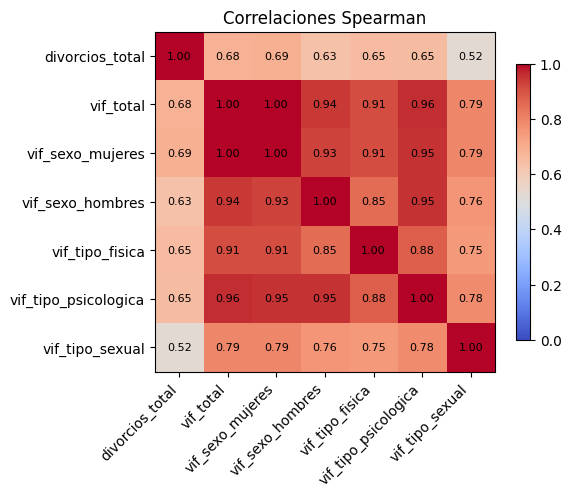

In [5]:
columnas_corr = ['divorcios_total', 'vif_total', 'vif_sexo_mujeres', 'vif_sexo_hombres',
                  'vif_tipo_fisica', 'vif_tipo_psicologica', 'vif_tipo_sexual']
corr_matrix = panel[columnas_corr].corr(method='spearman')
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=0, vmax=1)
ax.set_xticks(range(len(columnas_corr)))
ax.set_xticklabels(columnas_corr, rotation=45, ha='right')
ax.set_yticks(range(len(columnas_corr)))
ax.set_yticklabels(columnas_corr)
for i in range(len(columnas_corr)):
    for j in range(len(columnas_corr)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)
ax.set_title('Correlaciones Spearman')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

## Tabla por cuantiles de divorcios
Se agrupan los departamentos en cuartiles según divorcios para comparar los niveles
promedio de VIF total.

In [6]:
tabla_cuartiles = dp.vif_quartile_table(panel)
tabla_cuartiles

,media,mediana,maximo
div_q,,,
Q1,507.8,13.5,8381
Q2,1190.2,1088.0,4364
Q3,1896.2,1559.0,7936


### Interpretación
- Spearman=0.93 confirma una relación monótona fuerte: los departamentos con más divorcios
  también concentran VIF, aunque el log reduce la pendiente y mejora Pearson (0.88).
- El heatmap revela que `vif_sexo_mujeres` y `vif_tipo_física` son casi colineales con
  `vif_total`, por lo que basta incluir una de ellas en modelos para evitar multicolinealidad.
- Los cuartiles muestran que pasar de Q3→Q4 en divorcios multiplica por 4 el VIF promedio,
  lo que respalda la hipótesis de factores estructurales compartidos (tamaño poblacional, urbanización).

## Análisis de Disparidad Departamental (Ratios y Outliers)
Investigamos qué departamentos tienen una relación inusual entre violencia (VIF) y divorcios, calculando el ratio `Divorcios / VIF` y analizando los residuos de una regresión lineal.

Departamentos con MENOR ratio Divorcios/VIF (Mucha violencia, pocos divorcios):


,divorcios_total,vif_total,ratio_divorcio_vif
departamento,,,
Alta Verapaz,1425.0,42900,0.033217
Chimaltenango,1475.0,20406,0.072283
Sacatepéquez,1431.0,17134,0.083518
Suchitepéquez,2377.0,22765,0.104415
Retalhuleu,1920.0,17541,0.109458
El Progreso,1215.0,10887,0.111601
Sololá,753.0,6593,0.114212
Baja Verapaz,1240.0,10548,0.117558
San Marcos,2915.0,20748,0.140495


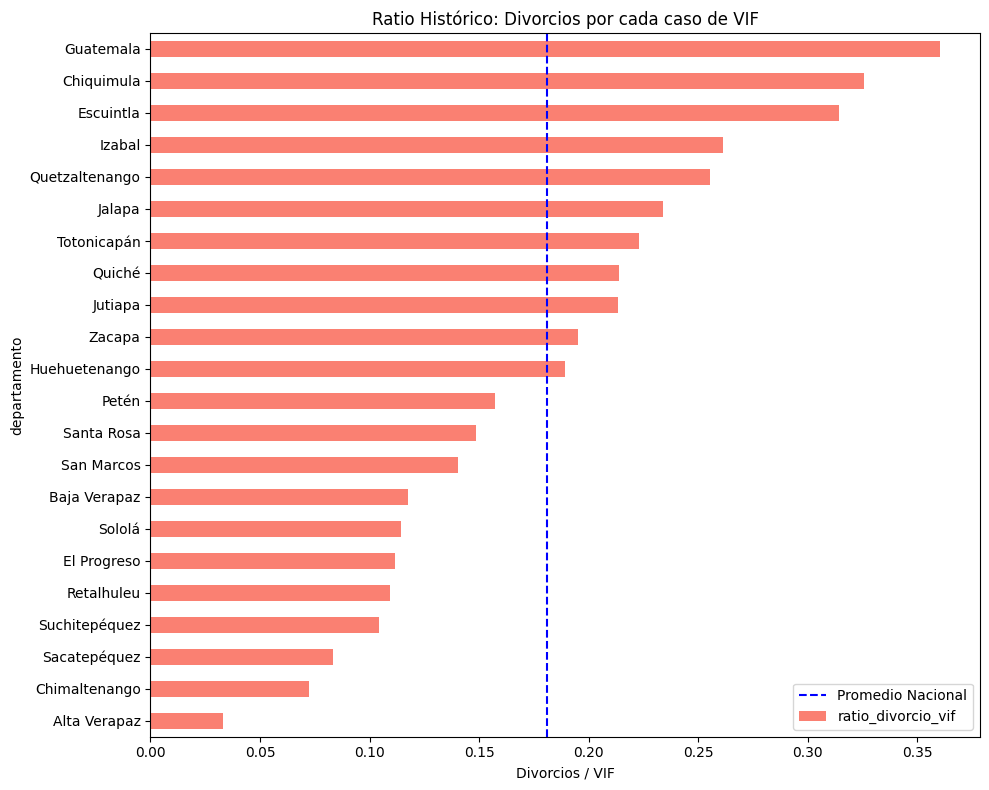

In [7]:
# Agrupar por departamento y calcular totales históricos
dept_stats = panel.groupby('departamento')[['divorcios_total', 'vif_total']].sum()

# Calcular ratio: Cuántos divorcios hay por cada caso de VIF registrado
# Un ratio bajo indica mucha violencia pero pocos divorcios (potencial sub-registro o barreras culturales/legales)
dept_stats['ratio_divorcio_vif'] = dept_stats['divorcios_total'] / dept_stats['vif_total']

# Ordenar por ratio ascendente (los más preocupantes primero)
print("Departamentos con MENOR ratio Divorcios/VIF (Mucha violencia, pocos divorcios):")
display(dept_stats.sort_values('ratio_divorcio_vif').head(10))

# Visualización de los Ratios
plt.figure(figsize=(10, 8))
dept_stats.sort_values('ratio_divorcio_vif', ascending=True)['ratio_divorcio_vif'].plot(kind='barh', color='salmon')
plt.title('Ratio Histórico: Divorcios por cada caso de VIF')
plt.xlabel('Divorcios / VIF')
plt.axvline(x=dept_stats['ratio_divorcio_vif'].mean(), color='blue', linestyle='--', label='Promedio Nacional')
plt.legend()
plt.tight_layout()
plt.show()

## Detección de Outliers usando Regresión
Usamos una regresión lineal sobre las variables transformadas (log) para predecir los divorcios "esperados" dado el nivel de violencia.
Los departamentos con residuos negativos grandes tienen **menos divorcios de los que el modelo predice** basándose en su nivel de violencia.

In [11]:
from sklearn.linear_model import LinearRegression

# Preparar datos transformados (log1p para manejar la asimetría y ceros)
X = np.log1p(dept_stats[['vif_total']])  # Predictor: Violencia
y = np.log1p(dept_stats['divorcios_total']) # Objetivo: Divorcios

# Ajustar modelo
model = LinearRegression()
model.fit(X, y)

# Calcular predicciones y residuos
dept_stats['log_divorcios_pred'] = model.predict(X)
dept_stats['divorcios_esperados'] = np.expm1(dept_stats['log_divorcios_pred'])
dept_stats['residuo_log'] = y - dept_stats['log_divorcios_pred']

# Identificar outliers negativos (Menos divorcios de lo esperado)
outliers = dept_stats.sort_values('residuo_log').head(5)

print("Top 5 Departamentos con 'Déficit' de Divorcios (Residuos Negativos):")
display(outliers[['divorcios_total', 'divorcios_esperados', 'vif_total', 'residuo_log']])

# Visualización: Scatter plot con línea de regresión y outliers destacados
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Departamentos')
plt.plot(X, dept_stats['log_divorcios_pred'], color='red', label='Tendencia Esperada')

# Destacar Alta Verapaz y otros outliers
for depto in outliers.index:
    plt.scatter(X.loc[depto], y.loc[depto], color='red', s=100, edgecolor='black')
    plt.text(X.loc[depto], y.loc[depto], f"  {depto}", fontsize=9, va='center')

plt.title('Relación Divorcios vs VIF (Log-Log) con Outliers')
plt.xlabel('log(VIF Total)')
plt.ylabel('log(Divorcios Total)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Top 5 Departamentos con 'Déficit' de Divorcios (Residuos Negativos):


,divorcios_total,divorcios_esperados,vif_total,residuo_log
departamento,,,,
Alta Verapaz,1425.0,4638.774194,42900,-1.179792
Chimaltenango,1475.0,2798.751283,20406,-0.640195
Sacatepéquez,1431.0,2485.123619,17134,-0.551653
Sololá,753.0,1297.876512,6593,-0.543863
El Progreso,1215.0,1825.573421,10887,-0.406875


TypeError: float() argument must be a string or a real number, not 'Series'

<Figure size 1000x600 with 1 Axes>